In [14]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from tarnet import Tarnet
import sys
from pathlib import Path
project_root = Path("/home/ducvu0904/Documents/Lab/RERUM")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
sys.path.append("..")
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [15]:
%time train_df = pd.read_csv(r"../dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"../dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"../dataset/Hillstrom/Men/val_men.csv")

CPU times: user 11.1 ms, sys: 4.01 ms, total: 15.2 ms
Wall time: 14.8 ms
CPU times: user 4.84 ms, sys: 1 ms, total: 5.84 ms
Wall time: 5.8 ms
CPU times: user 1.8 ms, sys: 1 ms, total: 2.81 ms
Wall time: 2.79 ms


In [16]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['spend']
treatment_feature = ['treatment']

In [17]:
# 1. Định nghĩa danh sách các cột (Bạn hãy điều chỉnh tên cột đúng với dữ liệu của mình)
cat_features = ['zip_code', 'channel', 'history_segment'] # Các biến phân loại (đã LabelEncode)
num_features = ['recency', 'history', 'mens', 'womens']     # Các biến số thực (đã Scale)

def prepare_tensors(df):
    """Hàm hỗ trợ chuyển đổi DataFrame thành các Tensor riêng biệt"""
    # Tách dữ liệu
    X_cat = torch.LongTensor(df[cat_features].values)    # Kiểu Long cho Embedding 
    X_num = torch.FloatTensor(df[num_features].values)  # Kiểu Float cho Projection 
    
    # Biến mục tiêu
    t = torch.FloatTensor(df['treatment'].values).unsqueeze(1)
    y = torch.FloatTensor(df['spend'].values).unsqueeze(1) # Lưu ý: Nên là log(1+y) [cite: 191]
    
    return X_cat, X_num, t, y

# 2. Chuyển đổi cho cả 3 tập dữ liệu [cite: 390]
train_cat, train_num, t_train, y_train = prepare_tensors(train_df)
val_cat, val_num, t_val, y_val = prepare_tensors(val_df)
test_cat, test_num, t_test, y_test = prepare_tensors(test_df)

# 3. Khởi tạo TensorDataset với cấu trúc 4 tham số
train_dataset = TensorDataset(train_cat, train_num, t_train, y_train)
val_dataset = TensorDataset(val_cat, val_num, t_val, y_val)
test_dataset = TensorDataset(test_cat, test_num, t_test, y_test)

# 4. Khởi tạo DataLoader [cite: 398, 419]
# Với 5060Ti, batch_size=1024 hoặc 2048 là tối ưu để gradient không quá phẳng
batch_size = 1024 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 5. Thông tin để khởi tạo Model
cat_dims = [train_df[col].nunique() for col in cat_features]
num_count = len(num_features)

print(f"Mô hình sẽ có {len(cat_dims)} lớp Embedding và {num_count} lớp Projection.")

Mô hình sẽ có 3 lớp Embedding và 4 lớp Projection.


In [18]:
epochs = 150
early_stop_metric = "ema_qini"
ema = True
patience = 20
early_stop_start = 30
print (f" epochs = {epochs}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" patience = {patience}")
print (f" early stop start = {early_stop_start}")

 epochs = 150
 early stop = ema_qini
 use ema = True
 patience = 20
 early stop start = 30


In [19]:
import io
import optuna
from contextlib import redirect_stdout, redirect_stderr

# Minimize Optuna console noise
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Optuna search config (validation only)
seeds = [412312, 42, 1874, 902745, 1]
n_trials = 100
tpe_sampler_seed = 412312
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):
    grid_lr = trial.suggest_float("lr", 1e-5,  1e-3, log=True)
    grid_wd = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    grid_outcome_dropout = trial.suggest_float("outcome_dropout", 0.0, 0.7)
    grid_shared_dropout = trial.suggest_float("shared_dropout", 0.0, 0.7)
    grid_outcome_hidden = trial.suggest_int("outcome_hidden", 32, 500)
    grid_shared_hidden = trial.suggest_int("shared_hidden", 32, 500)
    grid_uplift_ranking = trial.suggest_float("uplift_ranking", 1e-4, 100.0)
    grid_reponse_ranking = trial.suggest_float("response_ranking", 1e-4, 100.0)
    grid_ranking_start = trial.suggest_int("ranking_start", 0, 20, step=1)
    grid_ema_alpha = trial.suggest_float("ema_alpha", 0.0, 0.4)

    val_auqc_list = []
    val_ate_err_list = []
    for step, SEED in enumerate(seeds, start=1):
        seed_everything(SEED)

        tarnet = Tarnet(
            cate_dims=cat_dims,
            num_count=num_count,
            epochs=epochs,
            learning_rate=grid_lr,
            weight_decay=grid_wd,
            use_ema=ema,
            ema_alpha=grid_ema_alpha,
            patience=patience,
            shared_hidden=grid_shared_hidden,
            outcome_hidden=grid_outcome_hidden,
            outcome_dropout=grid_outcome_dropout,
            shared_dropout=grid_shared_dropout,
            early_stop_metric=early_stop_metric,
            early_stop_start_epoch=early_stop_start,
            uplift_ranking=grid_uplift_ranking,
            response_ranking=grid_reponse_ranking,
            ranking_start_epoch=grid_ranking_start
        )

        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            tarnet.fit(train_loader, val_loader)
        val_cat_device = val_cat.to(device)
        val_num_device = val_num.to(device)

        y0_pred, y1_pred = tarnet.predict(val_cat_device, val_num_device)
        
        uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
        y_true = y_val.detach().cpu().numpy().flatten()
        t_true = t_val.detach().cpu().numpy().flatten()
        
        current_val_auqc = auqc(y_true, t_true, uplift_pred, bins=100, plot=False)
        ate_pred = uplift_pred.mean()
        ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()
        current_val_ate_err = abs(ate_pred - ate_true)

        val_auqc_list.append(current_val_auqc)
        val_ate_err_list.append(current_val_ate_err)

    # Calculate aggregated metrics across the 5 validation seeds
    mean_auqc = float(np.mean(val_auqc_list))
    std_auqc = float(np.std(val_auqc_list))
    mean_ate_err = float(np.mean(val_ate_err_list))

    # Apply penalty for instability and miscalibration
    penalty_std = std_auqc

    final_score = mean_auqc - penalty_std

    trial.set_user_attr("mean_val_auqc", mean_auqc)
    trial.set_user_attr("std_Val_auqc", std_auqc)
    trial.set_user_attr("mean_val_ate_err", mean_ate_err)
    trial.set_user_attr("final_score", final_score) 
    return final_score

def print_trial_callback(study, trial):
    value = float(trial.value) if trial.value is not None else float("nan")
    best_trial = study.best_trial
    best_value = float(best_trial.value) if best_trial.value is not None else float("nan")
    print(
        f"Finished trial {trial.number}: score: {value:.4f} - "
        f"with hyperparameters: {trial.params} | "
        f"best trial: {best_trial.number} score: {best_value:.4f}",
        flush=True
    )

sampler = optuna.samplers.TPESampler(seed=tpe_sampler_seed)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials, show_progress_bar=True, callbacks=[print_trial_callback])

trial_rows = []
for t in study.trials:
    if t.value is None:
        continue
    trial_rows.append({
        "trial": t.number,
        "lr": round(float(t.params["lr"]), 4),
        "weight_decay": round(float(t.params["weight_decay"]), 4),
        "shared_hidden": int(t.params["shared_hidden"]),
        "outcome_hidden": int(t.params["outcome_hidden"]),
        "shared_dropout": round(float(t.params["shared_dropout"]), 3),
        "outcome_dropout": round(float(t.params["outcome_dropout"]), 3),
        "uplift_ranking": round(float(t.params["uplift_ranking"]), 4),
        "response_ranking": round(float(t.params["response_ranking"]), 4),
        "ranking_start": int(t.params["ranking_start"]),
        "ema_alpha": round(float(t.params["ema_alpha"]), 3),
        "mean_val_auqc": float(t.value),
        "std_Val_auqc": float(t.user_attrs.get("std_Val_auqc", np.nan))
    })

df_grid = pd.DataFrame(trial_rows).sort_values("mean_val_auqc", ascending=True).reset_index(drop=True)
best_params = study.best_params
best_cfg = pd.Series({
    "lr": float(best_params["lr"]),
    "weight_decay": float(best_params["weight_decay"]),
    "shared_hidden": int(best_params["shared_hidden"]),
    "outcome_hidden": int(best_params["outcome_hidden"]),
    "shared_dropout": float(best_params["shared_dropout"]),
    "outcome_dropout": float(best_params["outcome_dropout"]),
    "uplift_ranking": float(best_params["uplift_ranking"]),
    "response_ranking": float(best_params["response_ranking"]),
    "ranking_start": int(best_params["ranking_start"]),
    "ema_alpha": round(float(best_params["ema_alpha"]), 3),
    "mean_Val_auqc": float(study.best_value),
    "std_Val_auqc": float(study.best_trial.user_attrs.get("std_Val_auqc", np.nan))
})

  0%|          | 0/100 [00:00<?, ?it/s]

Finished trial 0: score: 0.8080 - with hyperparameters: {'lr': 9.008296332262975e-05, 'weight_decay': 3.2543813547868006e-05, 'outcome_dropout': 0.285791981486852, 'shared_dropout': 0.3103695462655224, 'outcome_hidden': 314, 'shared_hidden': 416, 'uplift_ranking': 93.47556399591086, 'response_ranking': 97.88862912745603, 'ranking_start': 12, 'ema_alpha': 0.29552991833362324} | best trial: 0 score: 0.8080


Best trial: 0. Best value: 0.808014:   1%|          | 1/100 [01:23<2:17:36, 83.40s/it]

Finished trial 1: score: 0.8335 - with hyperparameters: {'lr': 0.0004343428994476941, 'weight_decay': 1.7564582302056362e-05, 'outcome_dropout': 0.2919863338576562, 'shared_dropout': 0.12019291253634456, 'outcome_hidden': 133, 'shared_hidden': 345, 'uplift_ranking': 76.74493326874817, 'response_ranking': 60.726341502367255, 'ranking_start': 12, 'ema_alpha': 0.20655163273752133} | best trial: 1 score: 0.8335


Best trial: 1. Best value: 0.833498:   2%|▏         | 2/100 [02:43<2:13:06, 81.49s/it]

...

Best trial: 24. Best value: 0.853431:  98%|█████████▊| 98/100 [2:17:38<02:40, 80.48s/it]

Finished trial 98: score: 0.8334 - with hyperparameters: {'lr': 0.0004889086193619751, 'weight_decay': 0.0002983352493654307, 'outcome_dropout': 0.6653479305177595, 'shared_dropout': 0.12767587641007555, 'outcome_hidden': 408, 'shared_hidden': 430, 'uplift_ranking': 42.387335689827026, 'response_ranking': 94.63391215192206, 'ranking_start': 15, 'ema_alpha': 0.13478864102151106} | best trial: 24 score: 0.8534


Best trial: 24. Best value: 0.853431:  99%|█████████▉| 99/100 [2:18:56<01:19, 79.85s/it]

Finished trial 99: score: 0.7899 - with hyperparameters: {'lr': 0.0007607284505953354, 'weight_decay': 0.0018284889553754709, 'outcome_dropout': 0.19808948503680113, 'shared_dropout': 0.14468500256704747, 'outcome_hidden': 271, 'shared_hidden': 491, 'uplift_ranking': 40.78750689897519, 'response_ranking': 91.21075830016656, 'ranking_start': 9, 'ema_alpha': 0.123190976893476} | best trial: 24 score: 0.8534


Best trial: 24. Best value: 0.853431: 100%|██████████| 100/100 [2:20:16<00:00, 84.17s/it]


In [20]:
from IPython.display import display

if 'study' not in globals():
    print('Run Cell 10 (Optuna tuning) first.')
else:
    print(f"Best trial: {study.best_trial.number}")
    print(f"Best mean_Val_AUQC: {study.best_value:.6f}")
    print(f"Best params: {study.best_params}")

if 'best_cfg' in globals():
    print('\nBest config table:')
    display(best_cfg.to_frame().T)
else:
    print('\nbest_cfg not found.')

if 'df_grid' in globals():
    print('\nTop 10 trials:')
    display(df_grid.head(10))
else:
    print('\ndf_grid not found.')

if 'df_results' in globals():
    print('\nPer-seed test results:')
    display(df_results)
    print('\nTest metrics mean ± std:')
    display(df_results.drop(columns='Seed').agg(['mean', 'std']))

Best trial: 24
Best mean_Val_AUQC: 0.853431
Best params: {'lr': 0.000942760258623517, 'weight_decay': 0.00020012430236614857, 'outcome_dropout': 0.5576529681742602, 'shared_dropout': 0.15314748166323952, 'outcome_hidden': 163, 'shared_hidden': 384, 'uplift_ranking': 59.82828210410361, 'response_ranking': 99.67654193862894, 'ranking_start': 13, 'ema_alpha': 0.14307139179765865}

Best config table:


,lr,weight_decay,shared_hidden,outcome_hidden,shared_dropout,outcome_dropout,uplift_ranking,response_ranking,ranking_start,ema_alpha,mean_Val_auqc,std_Val_auqc
0,0.000943,0.0002,384.0,163.0,0.153147,0.557653,59.828282,99.676542,13.0,0.143,0.853431,0.012081



Top 10 trials:


,trial,lr,weight_decay,shared_hidden,outcome_hidden,shared_dropout,outcome_dropout,uplift_ranking,response_ranking,ranking_start,ema_alpha,mean_val_auqc,std_Val_auqc
0,78,0.0000,0.0004,465,253,0.138,0.589,96.7762,89.9757,0,0.039,0.389827,0.148035
1,8,0.0000,0.0000,41,490,0.602,0.258,63.3210,53.7280,19,0.173,0.524798,0.152516
2,10,0.0003,0.0000,494,39,0.005,0.656,22.4955,29.2281,6,0.026,0.600200,0.125566
3,4,0.0003,0.0000,122,245,0.667,0.326,42.6793,42.5814,11,0.202,0.658334,0.105814
4,20,0.0000,0.0000,372,69,0.133,0.564,84.9082,60.4352,11,0.245,0.689159,0.075905
5,5,0.0000,0.0001,195,322,0.179,0.075,92.9315,1.0609,3,0.186,0.695526,0.092434
6,50,0.0001,0.0019,162,170,0.541,0.150,47.8623,45.9050,12,0.129,0.716011,0.054459
7,7,0.0000,0.0000,183,201,0.197,0.329,78.3767,65.6189,20,0.205,0.734375,0.045539
8,15,0.0010,0.0000,248,145,0.102,0.398,52.6177,15.9041,1,0.259,0.734998,0.054062
9,3,0.0006,0.0000,411,321,0.206,0.120,64.0249,50.5166,13,0.078,0.747046,0.045542



Per-seed test results:


,Seed,AUUC,AUQC,Lift,KRCC,ATE_Err
0,4132312,0.547643,0.543015,1.299892,0.034927,0.097387
1,432,0.562201,0.558709,1.201410,0.067753,0.026019
2,11874,0.533950,0.530421,0.680672,0.024881,0.270323
3,9102745,0.512179,0.508419,0.939511,0.060062,0.016334
4,11,0.593787,0.589605,1.442087,0.108990,0.234892



Test metrics mean ± std:


,AUUC,AUQC,Lift,KRCC,ATE_Err
mean,0.549952,0.546034,1.112714,0.059323,0.128991
std,0.030658,0.030524,0.303335,0.032863,0.117775


Evaluating on test with best validation config:
  lr=9.4e-04, weight_decay=2.0e-04
  shared_hidden=384, outcome_hidden=163
  shared_dropout=0.153, outcome_dropout=0.558
  uplift_ranking=59, response_ranking=99
  response_ranking=99
  ranking_start=13
Number of seeds: 10
  ema_alpha=0.143
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 1543.6135 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 1543.6135 | Val Loss: 413.8695 | Val Qini: 0.8683 | EMA Qini: 0.8683 | Best EMA: 0.8683 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 105.5362 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 105.5362 | Val Loss: 413.7862 | Val Qini: 0.8297 | EMA Qini: 0.8628 | Best EMA: 0.8683 (patience: 0/20)
Epoch 3/150 | Base Loss: 1034.0771 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss:

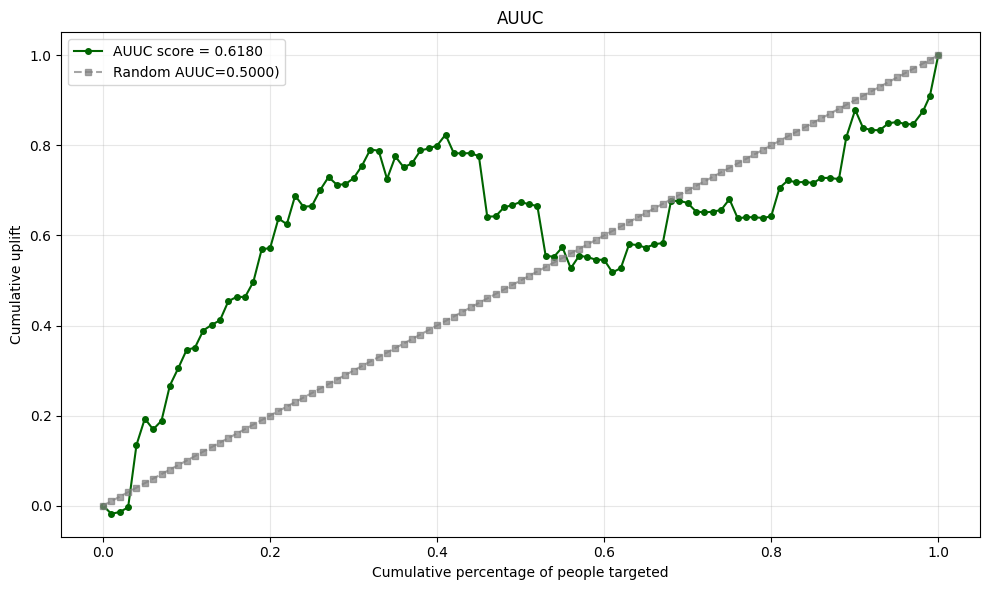

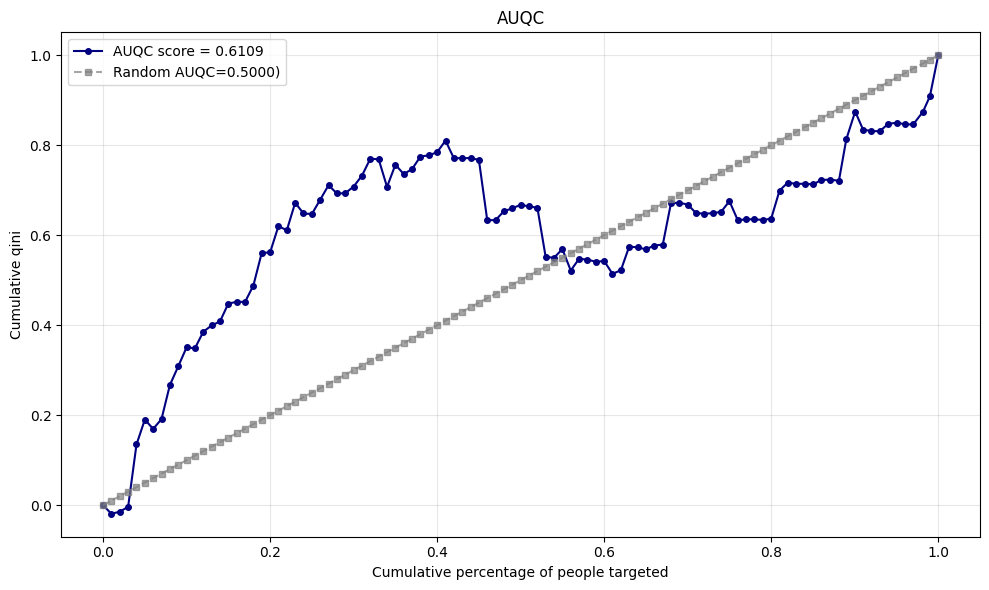

  Done Seed 412312
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 142.4294 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 142.4294 | Val Loss: 414.0195 | Val Qini: 0.7831 | EMA Qini: 0.7831 | Best EMA: 0.7831 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 690.4236 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 690.4236 | Val Loss: 413.4447 | Val Qini: 0.8576 | EMA Qini: 0.7937 | Best EMA: 0.7937 ⭐ NEW BEST EMA
Epoch 3/150 | Base Loss: 80.4149 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 80.4149 | Val Loss: 413.9028 | Val Qini: 0.7727 | EMA Qini: 0.7907 | Best EMA: 0.7937 (patience: 0/20)
Epoch 4/150 | Base Loss: 858.6846 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 858.6846 | Val Loss: 413.2670 | Val Qini: 0.8332 | EMA Qini: 0.7968 | Best

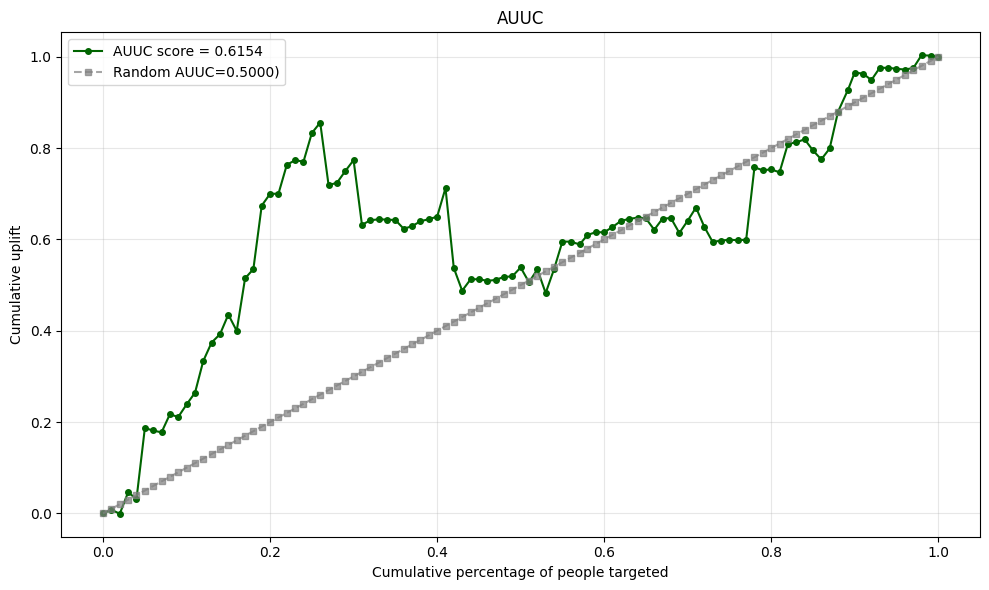

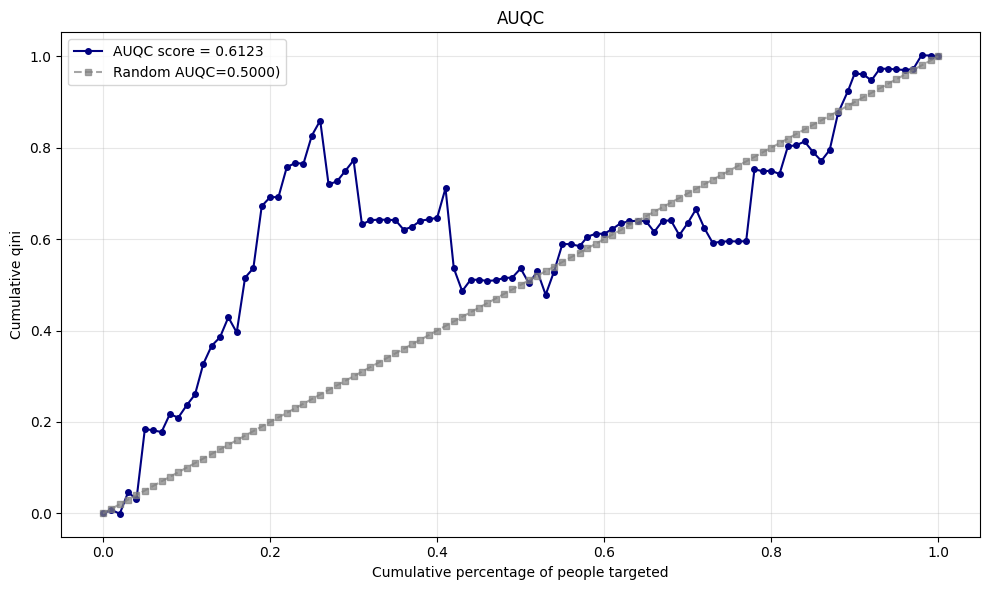

  Done Seed 42
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 351.1289 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 351.1289 | Val Loss: 414.0189 | Val Qini: 0.8750 | EMA Qini: 0.8750 | Best EMA: 0.8750 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 773.6249 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 773.6249 | Val Loss: 413.4914 | Val Qini: 0.7278 | EMA Qini: 0.8540 | Best EMA: 0.8750 (patience: 0/20)
Epoch 3/150 | Base Loss: 371.1781 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 371.1781 | Val Loss: 413.5047 | Val Qini: 0.7364 | EMA Qini: 0.8372 | Best EMA: 0.8750 (patience: 0/20)
Epoch 4/150 | Base Loss: 1484.2495 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 1484.2495 | Val Loss: 413.4473 | Val Qini: 0.8071 | EMA Qini: 0.8329 | Be

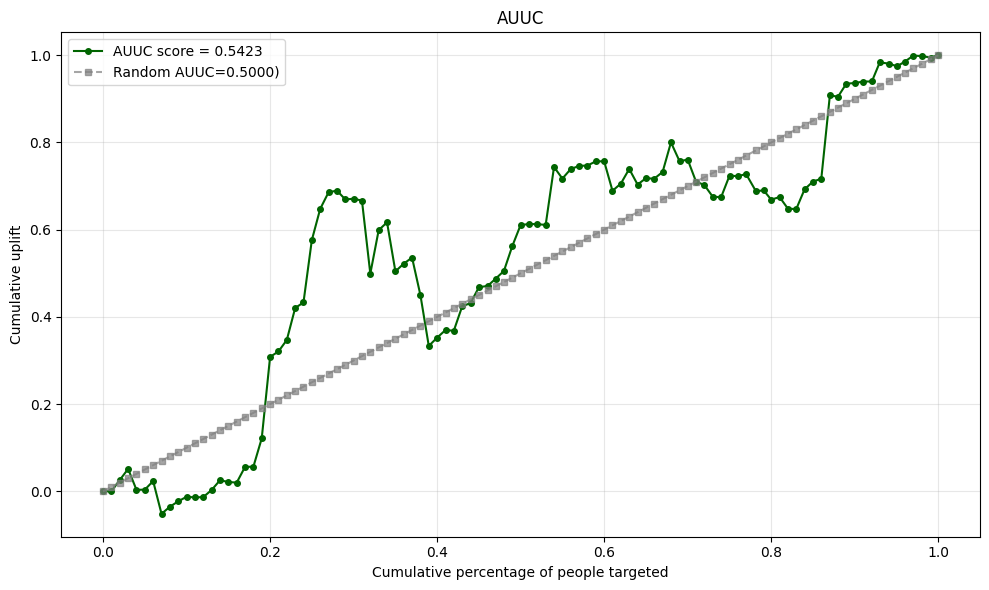

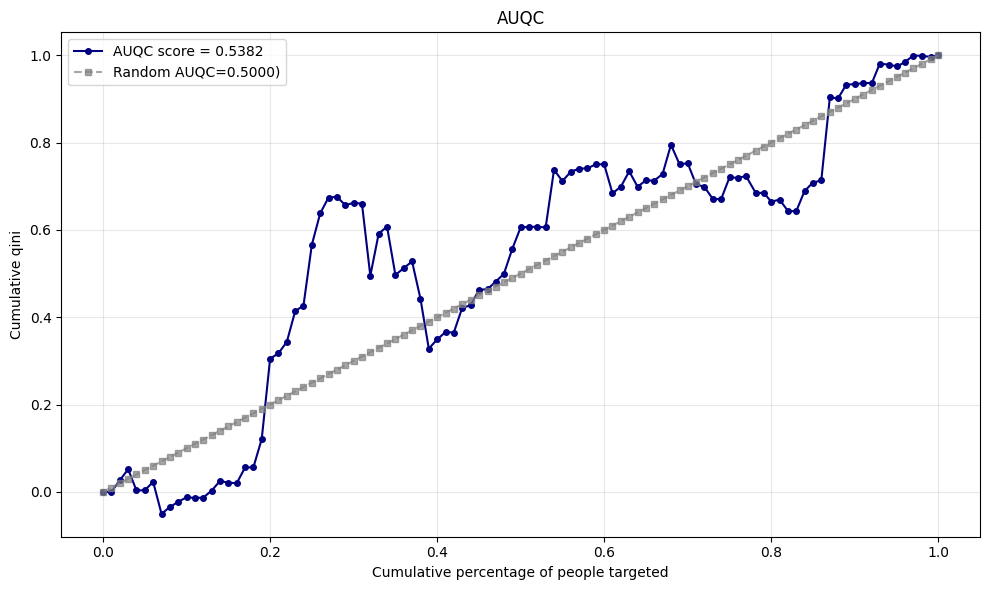

  Done Seed 1874
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 919.9443 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 919.9443 | Val Loss: 414.0183 | Val Qini: 0.8264 | EMA Qini: 0.8264 | Best EMA: 0.8264 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 247.5416 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 247.5416 | Val Loss: 413.5188 | Val Qini: 0.8380 | EMA Qini: 0.8280 | Best EMA: 0.8280 ⭐ NEW BEST EMA
Epoch 3/150 | Base Loss: 521.3017 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 521.3017 | Val Loss: 413.3434 | Val Qini: 0.8430 | EMA Qini: 0.8302 | Best EMA: 0.8302 ⭐ NEW BEST EMA
Epoch 4/150 | Base Loss: 466.3297 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 466.3297 | Val Loss: 413.4280 | Val Qini: 0.7926 | EMA Qini: 0.8248 | Best E

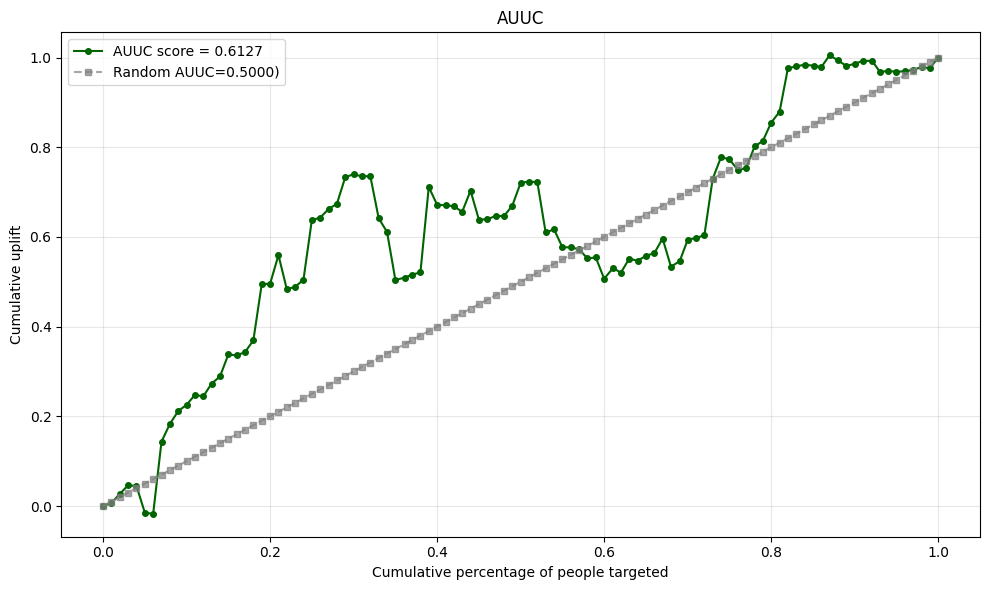

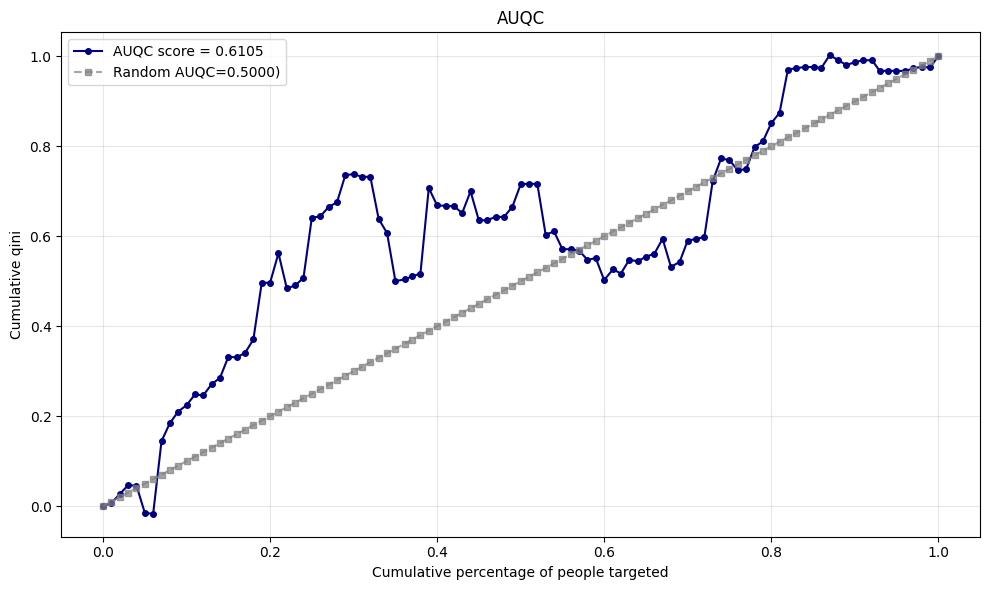

  Done Seed 902745
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 1307.7213 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 1307.7213 | Val Loss: 414.0487 | Val Qini: 0.8651 | EMA Qini: 0.8651 | Best EMA: 0.8651 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 203.3957 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 203.3957 | Val Loss: 413.6081 | Val Qini: 0.8376 | EMA Qini: 0.8612 | Best EMA: 0.8651 (patience: 0/20)
Epoch 3/150 | Base Loss: 491.3442 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 491.3442 | Val Loss: 413.2879 | Val Qini: 0.8383 | EMA Qini: 0.8579 | Best EMA: 0.8651 (patience: 0/20)
Epoch 4/150 | Base Loss: 1239.5359 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 1239.5359 | Val Loss: 413.4515 | Val Qini: 0.8200 | EMA Qini: 0.852

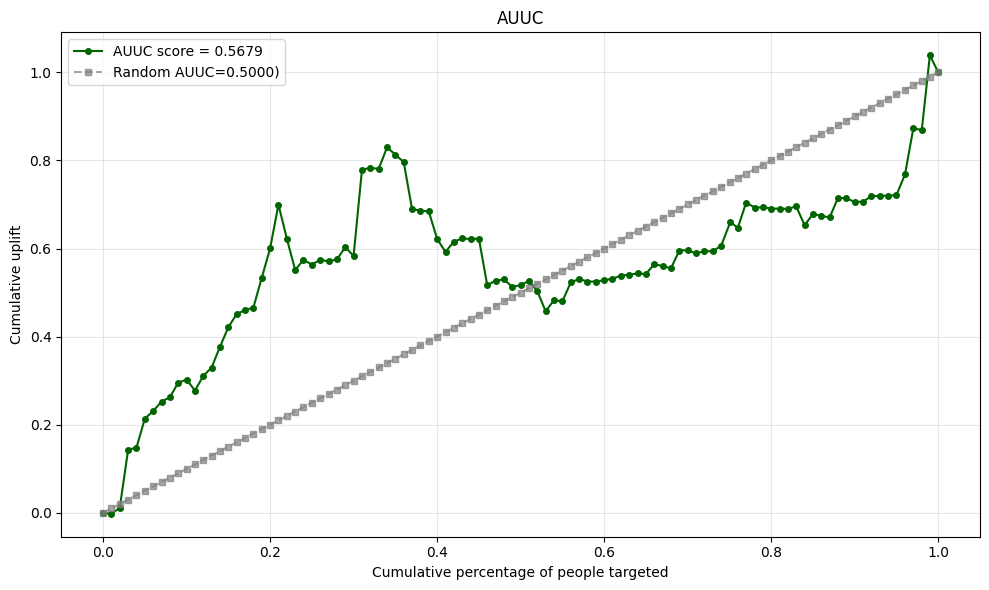

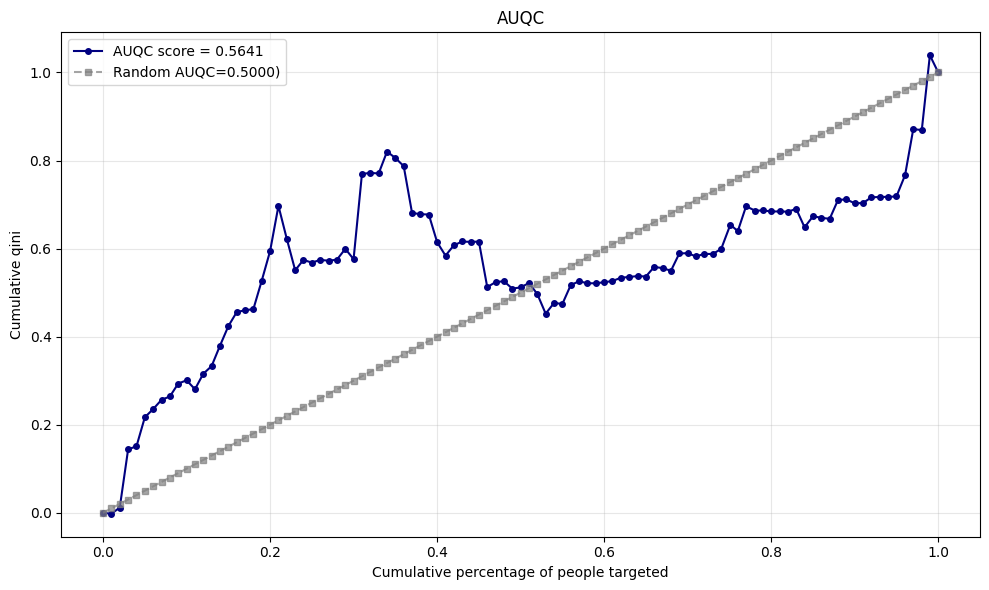

  Done Seed 1
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 371.4594 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 371.4594 | Val Loss: 413.6034 | Val Qini: 0.8492 | EMA Qini: 0.8492 | Best EMA: 0.8492 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 592.4384 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 592.4384 | Val Loss: 413.5046 | Val Qini: 0.8189 | EMA Qini: 0.8449 | Best EMA: 0.8492 (patience: 0/20)
Epoch 3/150 | Base Loss: 72.2391 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 72.2391 | Val Loss: 413.5439 | Val Qini: 0.7753 | EMA Qini: 0.8349 | Best EMA: 0.8492 (patience: 0/20)
Epoch 4/150 | Base Loss: 70.9662 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 70.9662 | Val Loss: 413.3989 | Val Qini: 0.7618 | EMA Qini: 0.8245 | Best EMA:

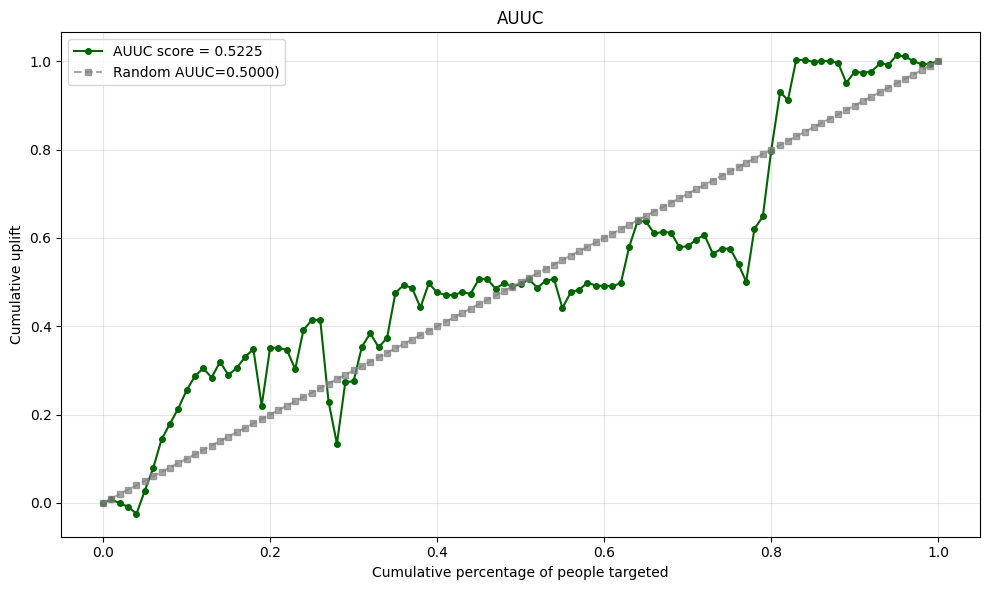

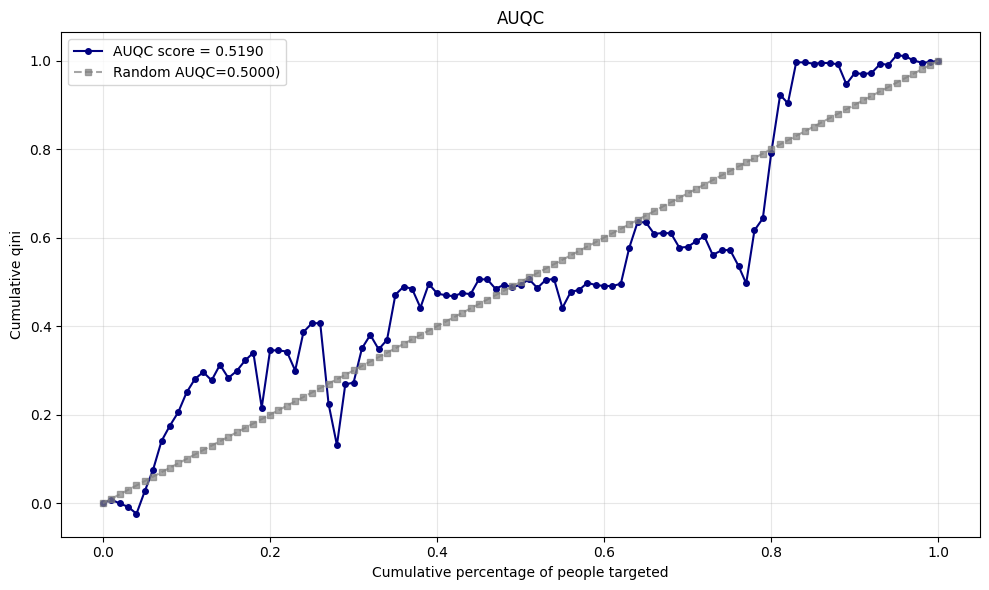

  Done Seed 2
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 472.1968 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 472.1968 | Val Loss: 413.6852 | Val Qini: 0.8568 | EMA Qini: 0.8568 | Best EMA: 0.8568 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 1047.9886 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 1047.9886 | Val Loss: 413.4397 | Val Qini: 0.8660 | EMA Qini: 0.8581 | Best EMA: 0.8581 ⭐ NEW BEST EMA
Epoch 3/150 | Base Loss: 795.1710 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 795.1710 | Val Loss: 413.4785 | Val Qini: 0.8526 | EMA Qini: 0.8573 | Best EMA: 0.8581 (patience: 0/20)
Epoch 4/150 | Base Loss: 364.7908 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 364.7908 | Val Loss: 413.7502 | Val Qini: 0.8027 | EMA Qini: 0.8495 | Best 

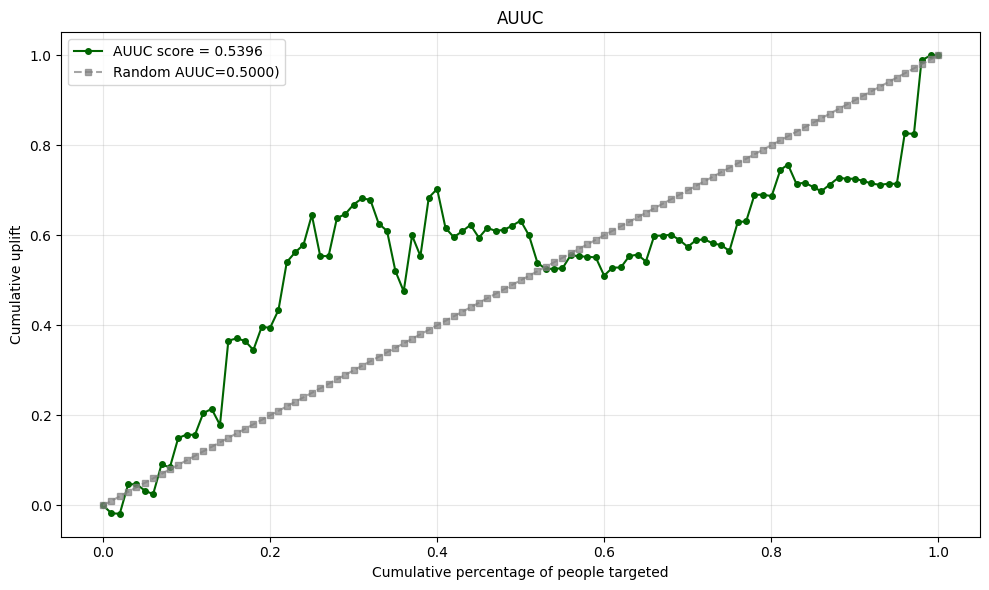

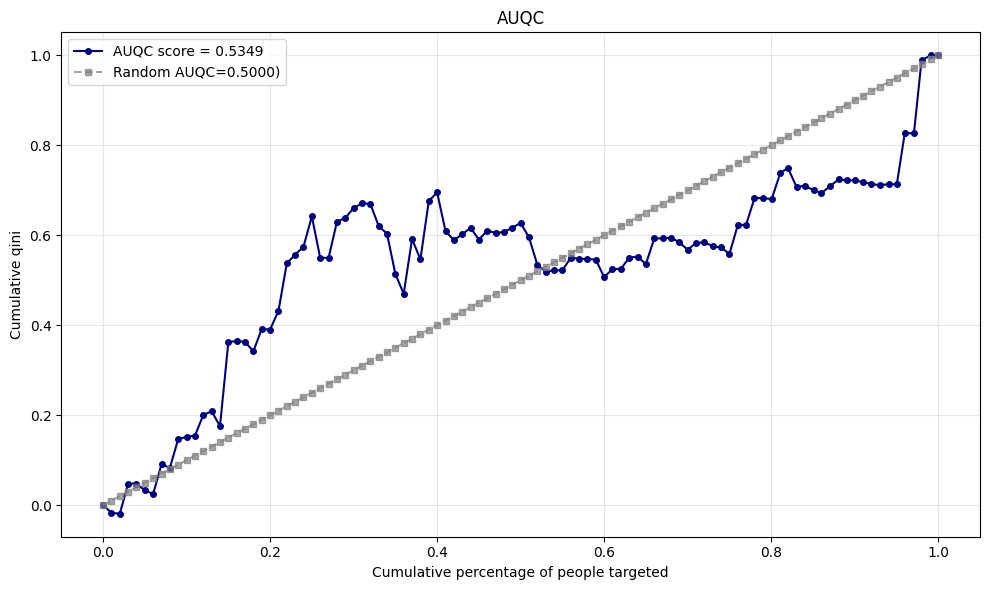

  Done Seed 3
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 735.4594 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 735.4594 | Val Loss: 413.9576 | Val Qini: 0.8319 | EMA Qini: 0.8319 | Best EMA: 0.8319 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 189.9077 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 189.9077 | Val Loss: 414.0180 | Val Qini: 0.8019 | EMA Qini: 0.8276 | Best EMA: 0.8319 (patience: 0/20)
Epoch 3/150 | Base Loss: 435.7238 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 435.7238 | Val Loss: 413.4425 | Val Qini: 0.8036 | EMA Qini: 0.8242 | Best EMA: 0.8319 (patience: 0/20)
Epoch 4/150 | Base Loss: 450.8985 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 450.8985 | Val Loss: 413.7055 | Val Qini: 0.8273 | EMA Qini: 0.8246 | Best 

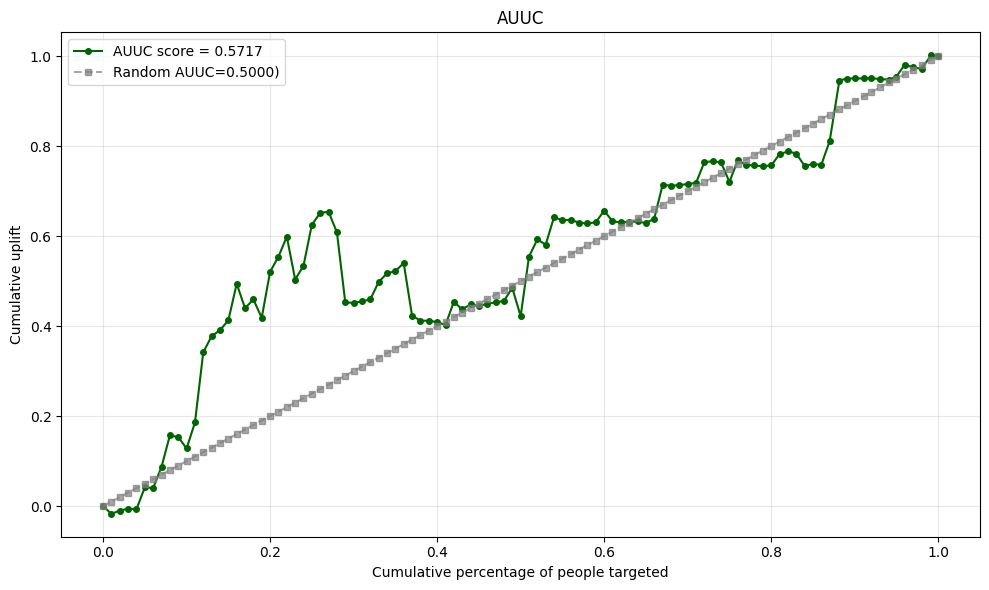

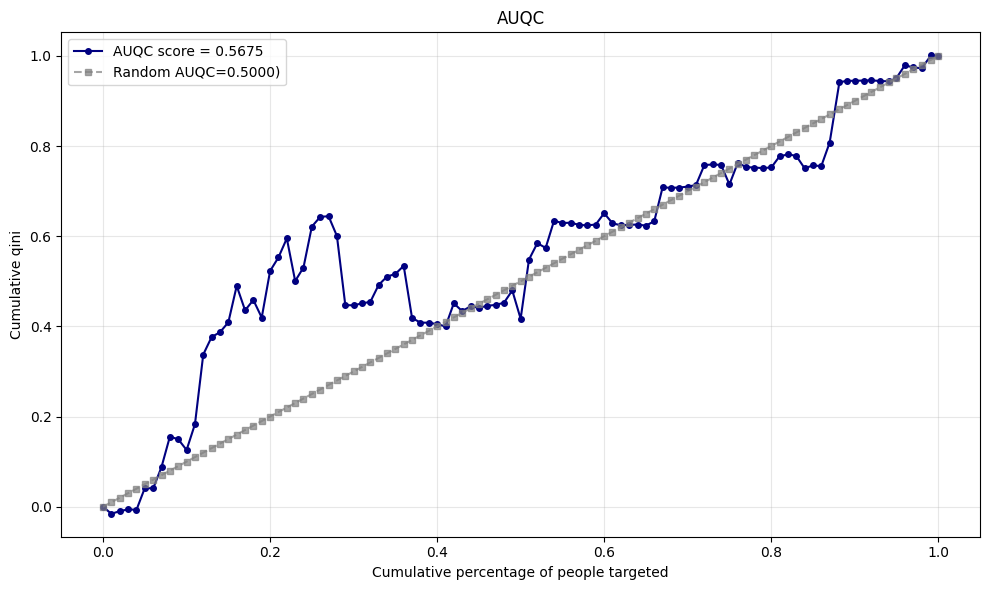

  Done Seed 4
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 230.6143 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 230.6143 | Val Loss: 413.7423 | Val Qini: 0.8155 | EMA Qini: 0.8155 | Best EMA: 0.8155 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 440.8791 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 440.8791 | Val Loss: 413.4351 | Val Qini: 0.7987 | EMA Qini: 0.8131 | Best EMA: 0.8155 (patience: 0/20)
Epoch 3/150 | Base Loss: 368.3873 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 368.3873 | Val Loss: 413.3045 | Val Qini: 0.8264 | EMA Qini: 0.8150 | Best EMA: 0.8155 (patience: 0/20)
Epoch 4/150 | Base Loss: 434.8773 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 434.8773 | Val Loss: 413.2807 | Val Qini: 0.8101 | EMA Qini: 0.8143 | Best 

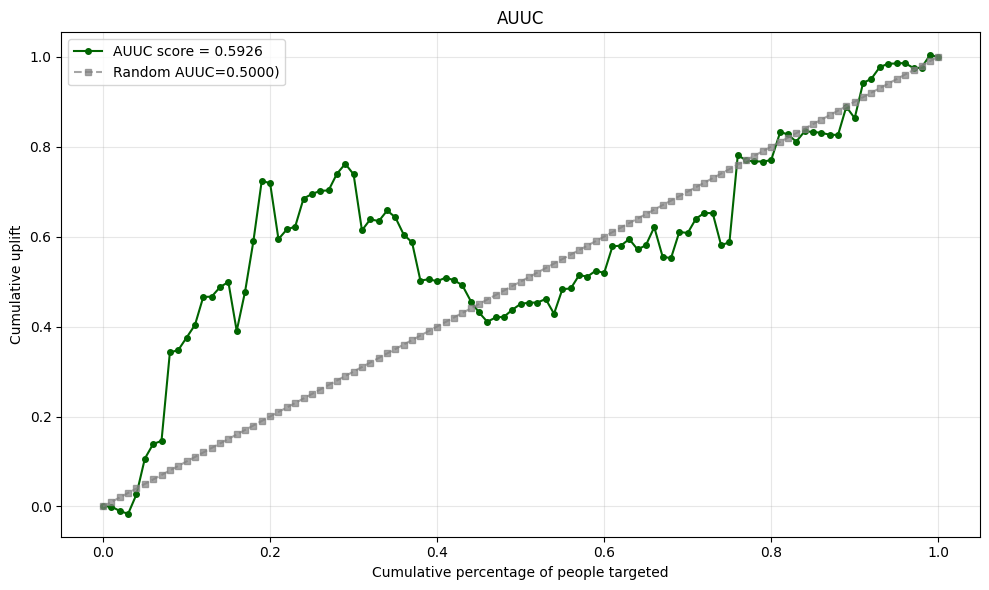

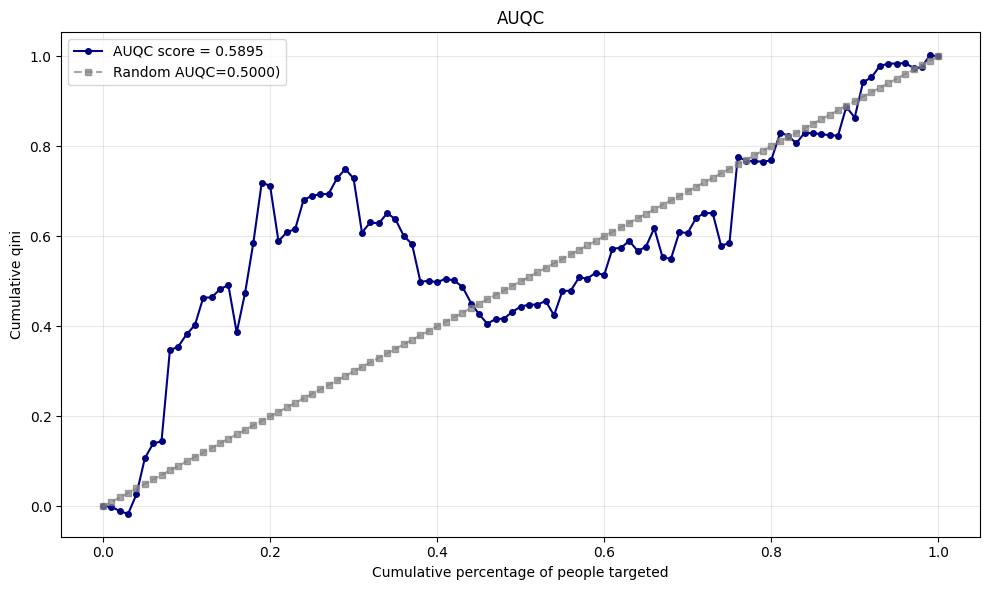

  Done Seed 5
🔃🔃🔃Begin training Tarnet🔃🔃🔃
📊 Early Stop Metric: EMA_QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Best EMA Qini (alpha=0.143)
   Restore to epoch with highest smoothed (EMA) Qini score
   Patience: 20 epochs
Epoch 1/150 | Base Loss: 131.7438 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 131.7438 | Val Loss: 414.2896 | Val Qini: 0.8065 | EMA Qini: 0.8065 | Best EMA: 0.8065 ⭐ NEW BEST EMA
Epoch 2/150 | Base Loss: 430.3872 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 430.3872 | Val Loss: 413.5096 | Val Qini: 0.8457 | EMA Qini: 0.8121 | Best EMA: 0.8121 ⭐ NEW BEST EMA
Epoch 3/150 | Base Loss: 691.5139 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 691.5139 | Val Loss: 413.3489 | Val Qini: 0.8252 | EMA Qini: 0.8140 | Best EMA: 0.8140 ⭐ NEW BEST EMA
Epoch 4/150 | Base Loss: 839.0895 | Uplift Loss: 0.000000 | Response Loss: 0.000000 | Total Loss: 839.0895 | Val Loss: 413.2133 | Val Qini: 0.8553 | EMA Qini: 0.8199 | Best EMA:

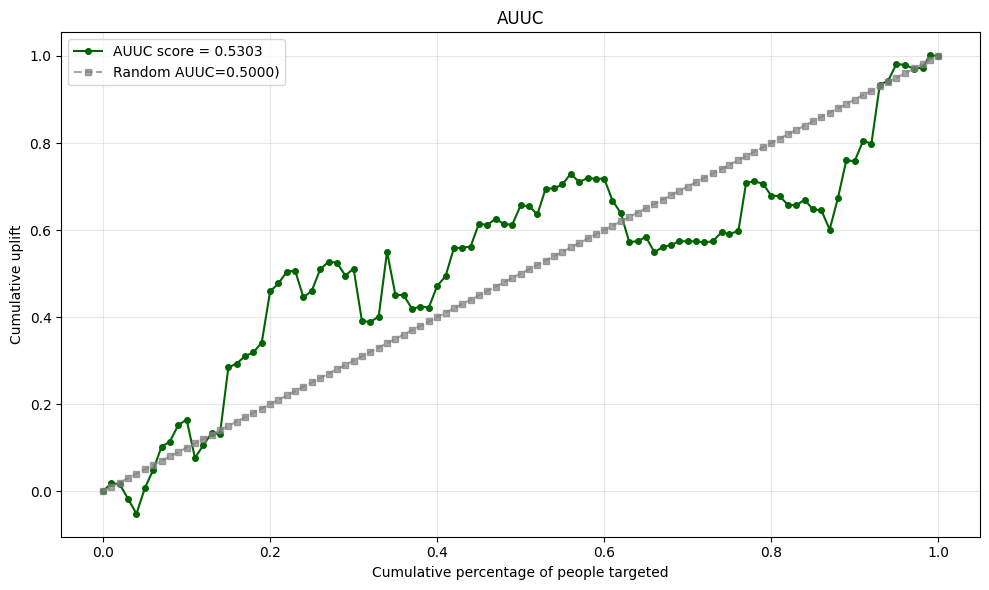

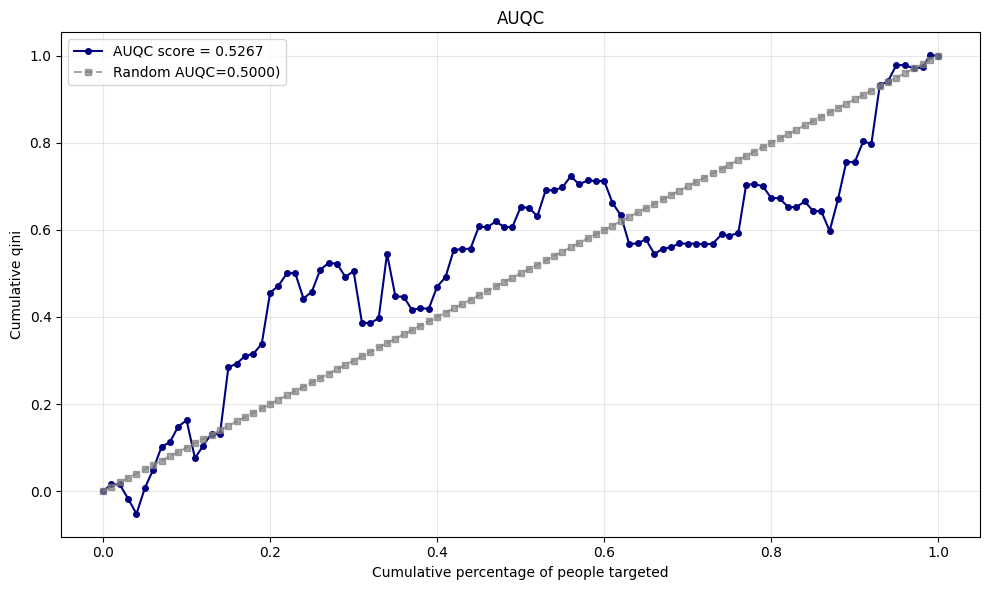

  Done Seed 6

                             PER-SEED DETAILS (TEST SET)                             
  Seed   AUUC   AUQC   Lift   KRCC ATE_Err
412312 0.6180 0.6109 1.4236 0.1068  0.1606
    42 0.6154 0.6123 1.5136 0.0913  0.2068
  1874 0.5423 0.5382 1.3140 0.0989  0.0650
902745 0.6127 0.6105 1.4472 0.1044  0.0191
     1 0.5679 0.5641 1.1425 0.0875  0.0465
     2 0.5225 0.5190 0.5389 0.0978  0.1004
     3 0.5396 0.5349 1.3092 0.0128  0.5428
     4 0.5717 0.5675 0.8850 0.0953  0.1028
     5 0.5926 0.5895 1.4464 0.0556  0.0680
     6 0.5303 0.5267 1.0008 0.1002  0.0853
                              TEST SUMMARY (MEAN ± STD)                              
-------------------------------------------------------------------------------------
AUUC      : 0.5713 ± 0.0368
AUQC      : 0.5674 ± 0.0368
Lift      : 1.2021 ± 0.3117
KRCC      : 0.0851 ± 0.0292
ATE_Err   : 0.1397 ± 0.1517


In [25]:
import pandas as pd
import numpy as np
import torch

# 1. Evaluate selected config on test set (after tuning)
seeds = [412312, 42, 1874, 902745, 1, 2, 3, 4, 5, 6] # Extended to 10 seeds for more robust evaluation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
all_runs = []

if 'best_cfg' not in globals():
    raise ValueError("best_cfg not found. Run grid-search cell first.")

best_lr = float(best_cfg['lr'])
best_wd = float(best_cfg['weight_decay'])
best_shared_hidden = int(best_cfg['shared_hidden'])
best_outcome_hidden = int(best_cfg['outcome_hidden'])
best_shared_dropout = float(best_cfg['shared_dropout'])
best_outcome_dropout = float(best_cfg['outcome_dropout'])
best_uplift_ranking = int(best_cfg['uplift_ranking'])
best_response_ranking = int(best_cfg['response_ranking'])
best_ranking_start = int(best_cfg['ranking_start'])
best_ema_alpha = float(best_cfg['ema_alpha'])

print("Evaluating on test with best validation config:")
print(f"  lr={best_lr:.1e}, weight_decay={best_wd:.1e}")
print(f"  shared_hidden={best_shared_hidden}, outcome_hidden={best_outcome_hidden}")
print(f"  shared_dropout={best_shared_dropout:.3f}, outcome_dropout={best_outcome_dropout:.3f}")
print(f"  uplift_ranking={best_uplift_ranking}, response_ranking={best_response_ranking}")
print(f"  response_ranking={best_response_ranking}")
print(f"  ranking_start={best_ranking_start}")
print(f"Number of seeds: {len(seeds)}")
print(f"  ema_alpha={best_ema_alpha:.3f}")
# 2. Loop over seeds for robust test evaluation
for SEED in seeds:
    seed_everything(SEED)

    tarnet = Tarnet(
        cate_dims=cat_dims,
        num_count=num_count,
        epochs=epochs,
        learning_rate=best_lr,
        weight_decay=best_wd,
        use_ema=ema,
        ema_alpha=best_ema_alpha,
        patience=patience,
        shared_hidden=best_shared_hidden,
        outcome_hidden=best_outcome_hidden,
        outcome_dropout=best_outcome_dropout,
        shared_dropout=best_shared_dropout,
        early_stop_metric=early_stop_metric,
        early_stop_start_epoch=early_stop_start,
        uplift_ranking=best_uplift_ranking,
        response_ranking=best_response_ranking,
        ranking_start_epoch=best_ranking_start

    )

    tarnet.fit(train_loader, val_loader)

    # Test prediction
    test_cat_device = test_cat.to(device)
    test_num_device = test_num.to(device)
    y0_pred, y1_pred = tarnet.predict(test_cat_device, test_num_device)

    uplift_pred = (y1_pred - y0_pred).detach().cpu().numpy().flatten()
    y_true = y_test.detach().cpu().numpy().flatten()
    t_true = t_test.detach().cpu().numpy().flatten()

    # ATE error
    ate_pred = uplift_pred.mean()
    ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

    all_runs.append({
        'Seed': SEED,
        'AUUC': auuc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'AUQC': auqc(y_true, t_true, uplift_pred, bins=100, plot=True),
        'Lift': lift(y_true, t_true, uplift_pred, h=0.3),
        'KRCC': krcc(y_true, t_true, uplift_pred, bins=100),
        'ATE_Err': abs(ate_pred - ate_true)
    })
    print(f"  Done Seed {SEED}")

# 3. Aggregate final test metrics
df_results = pd.DataFrame(all_runs)

print("\n" + "=" * 85)
print(f"{'PER-SEED DETAILS (TEST SET)':^85}")
print("=" * 85)
print(df_results.to_string(index=False, formatters={
    'AUUC': '{:,.4f}'.format,
    'AUQC': '{:,.4f}'.format,
    'Lift': '{:,.4f}'.format,
    'KRCC': '{:,.4f}'.format,
    'ATE_Err': '{:,.4f}'.format
}))

mean_res = df_results.drop(columns='Seed').mean()
std_res = df_results.drop(columns='Seed').std()

print("=" * 85)
print(f"{'TEST SUMMARY (MEAN ± STD)':^85}")
print("-" * 85)
for metric in ['AUUC', 'AUQC', 'Lift', 'KRCC', 'ATE_Err']:
    print(f"{metric:<10}: {mean_res[metric]:.4f} ± {std_res[metric]:.4f}")
print("=" * 85)